# 08 · Importancia de variables y entrenamiento con las más importantes

Con el LightGBM ganador del notebook 07 (F1 0,6972 en diciembre, 0,7142 en Kaggle): importancia por ganancia y por permutación en diciembre, y reentrenamiento con las 20, 30, 40, 50, 60 y 80 variables más importantes bajo la misma validación temporal de tres cortes. Si algún subconjunto iguala o supera a las 100, se genera `submission_v5.csv` con él.

1. Datos y modelo de referencia · 2. Importancia por ganancia y por permutación · 3. Reentrenamiento por número de variables · 4. Resultado y Kaggle

In [1]:
import warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import lightgbm as lgb
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

warnings.filterwarnings("ignore"); pd.set_option("display.width", 200, "display.max_columns", 60)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"; PROC = DATA / "processed"; OUT = ROOT / "outputs"; (ROOT / "models").mkdir(exist_ok=True)
C_BLUE, C_ORANGE, C_GRAY, C_MUTED = "#2a78d6", "#eb6834", "#c9c8c3", "#52514e"
mpl.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": C_GRAY, "axes.grid": True, "grid.color": "#ececea",
                     "axes.axisbelow": True, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.labelcolor": C_MUTED, "xtick.color": C_MUTED, "ytick.color": C_MUTED})
SEED = 42; NJ = 8
import sys; sys.path.insert(0, str(ROOT / "src"))
from tracking import grupo, registrar_busqueda, registrar_final, anexar, resumen
TAGS = {"notebook": "08_importancia_variables", "validacion": "temporal_3_cortes", "particion": "train<=t-1 / val t, t in {oct,nov,dic}"}

## 1. Datos y modelo de referencia

Las 100 variables del 06 y los hiperparámetros del LightGBM ganador del 07. Se reentrena hasta noviembre y se mide en diciembre para tener la referencia sobre la que se calcula la permutación.

In [2]:
train = pd.read_parquet(PROC / "train_fe.parquet"); test = pd.read_parquet(PROC / "test_fe.parquet")
FEATS = pd.read_csv(PROC / "features_fe.csv").feature.tolist(); TARGET = "var_rpta_alt"
CAT = [c for c in FEATS if str(train[c].dtype) == "category"]
for c in CAT:
    cats = pd.api.types.union_categoricals([train[c], test[c]]).categories
    train[c] = pd.Categorical(train[c], categories=cats); test[c] = pd.Categorical(test[c], categories=cats)
y = train[TARGET]; mes = train.fecha_var_rpta_alt
P_LGB = {"objective": "binary", "learning_rate": 0.021138128828094058, "num_leaves": 105, "min_child_samples": 108, "subsample": 0.8650089137415928, "subsample_freq": 1,
         "colsample_bytree": 0.5870266456536466, "reg_lambda": 3.4052591913244687, "reg_alpha": 2.7335513967163982, "random_state": SEED, "verbose": -1, "n_jobs": NJ}
CORTES = [202310, 202311, 202312]

def mejor_umbral(y_true, p):
    grid = np.arange(0.20, 0.81, 0.01); f1s = [f1_score(y_true, p >= u) for u in grid]; return float(grid[int(np.argmax(f1s))]), float(max(f1s))
def fit(cols, m_val, n_max=3000):
    tr = mes < m_val; va = mes == m_val
    m = lgb.LGBMClassifier(**P_LGB, n_estimators=n_max)
    m.fit(train.loc[tr, cols], y[tr], eval_set=[(train.loc[va, cols], y[va])], categorical_feature=[c for c in cols if c in CAT], callbacks=[lgb.early_stopping(80, verbose=False)])
    return m
def evaluar_temporal(cols):
    det = []
    for mv in CORTES:
        m = fit(cols, mv); va = mes == mv; p = m.predict_proba(train.loc[va, cols])[:, 1]; u, f1 = mejor_umbral(y[va], p)
        det.append({"corte": mv, "F1": f1, "AUC": roc_auc_score(y[va], p), "umbral": u, "n_arboles": m.best_iteration_})
    det = pd.DataFrame(det); return float(det.F1.mean()), det

t0 = time.time(); ref = fit(FEATS, 202312); va = mes == 202312; X_dic, y_dic = train.loc[va, FEATS], y[va]
p_ref = ref.predict_proba(X_dic)[:, 1]; U_REF, F1_REF = mejor_umbral(y_dic, p_ref)
print(f"Referencia (100 variables, hasta nov -> dic): F1 {F1_REF:.4f} | AUC {roc_auc_score(y_dic, p_ref):.4f} | umbral {U_REF:.2f} | {ref.best_iteration_} árboles | {time.time()-t0:.0f} s")

Referencia (100 variables, hasta nov -> dic): F1 0.6972 | AUC 0.7659 | umbral 0.33 | 1093 árboles | 53 s


## 2. Importancia por ganancia y por permutación

- **Ganancia**: cuánto reduce la pérdida cada variable dentro del modelo. Rápida, pero favorece a las numéricas con muchos valores y reparte la importancia entre variables correlacionadas.
- **Permutación en diciembre**: se baraja una variable en los datos de diciembre y se mide cuánto cae el F1 (con el umbral de referencia fijo). Se repite 3 veces y se promedia. Es la medida honesta, porque se calcula sobre datos que el modelo no usó para ajustarse. Una caída de cero o negativa significa que la variable no aporta.

In [3]:
imp_gain = pd.Series(ref.booster_.feature_importance("gain"), index=FEATS); imp_gain = imp_gain / imp_gain.sum()
rng = np.random.RandomState(SEED); t0 = time.time(); caidas = {}
for c in FEATS:
    vals = []
    for rep in range(3):
        Xp = X_dic.copy(); Xp[c] = Xp[c].values[rng.permutation(len(Xp))]
        vals.append(F1_REF - f1_score(y_dic, ref.predict_proba(Xp)[:, 1] >= U_REF))
    caidas[c] = np.mean(vals)
imp_perm = pd.Series(caidas).sort_values(ascending=False)
print(f"Permutación: {time.time()-t0:.0f} s | variables con caída <= 0: {(imp_perm <= 0).sum()} de {len(FEATS)}")
tabla_imp = pd.DataFrame({"ganancia": imp_gain, "caida_F1_permutacion": imp_perm}).sort_values("caida_F1_permutacion", ascending=False)
tabla_imp["rank_ganancia"] = tabla_imp.ganancia.rank(ascending=False).astype(int); tabla_imp["rank_permutacion"] = np.arange(1, len(tabla_imp) + 1)
tabla_imp.to_csv(OUT / "importancia_08.csv")

Permutación: 1142 s | variables con caída <= 0: 21 de 100


Las 30 variables con mayor caída de F1 al permutarlas (izquierda) y las 30 con mayor ganancia (derecha). Naranja = variables nuevas del 06.

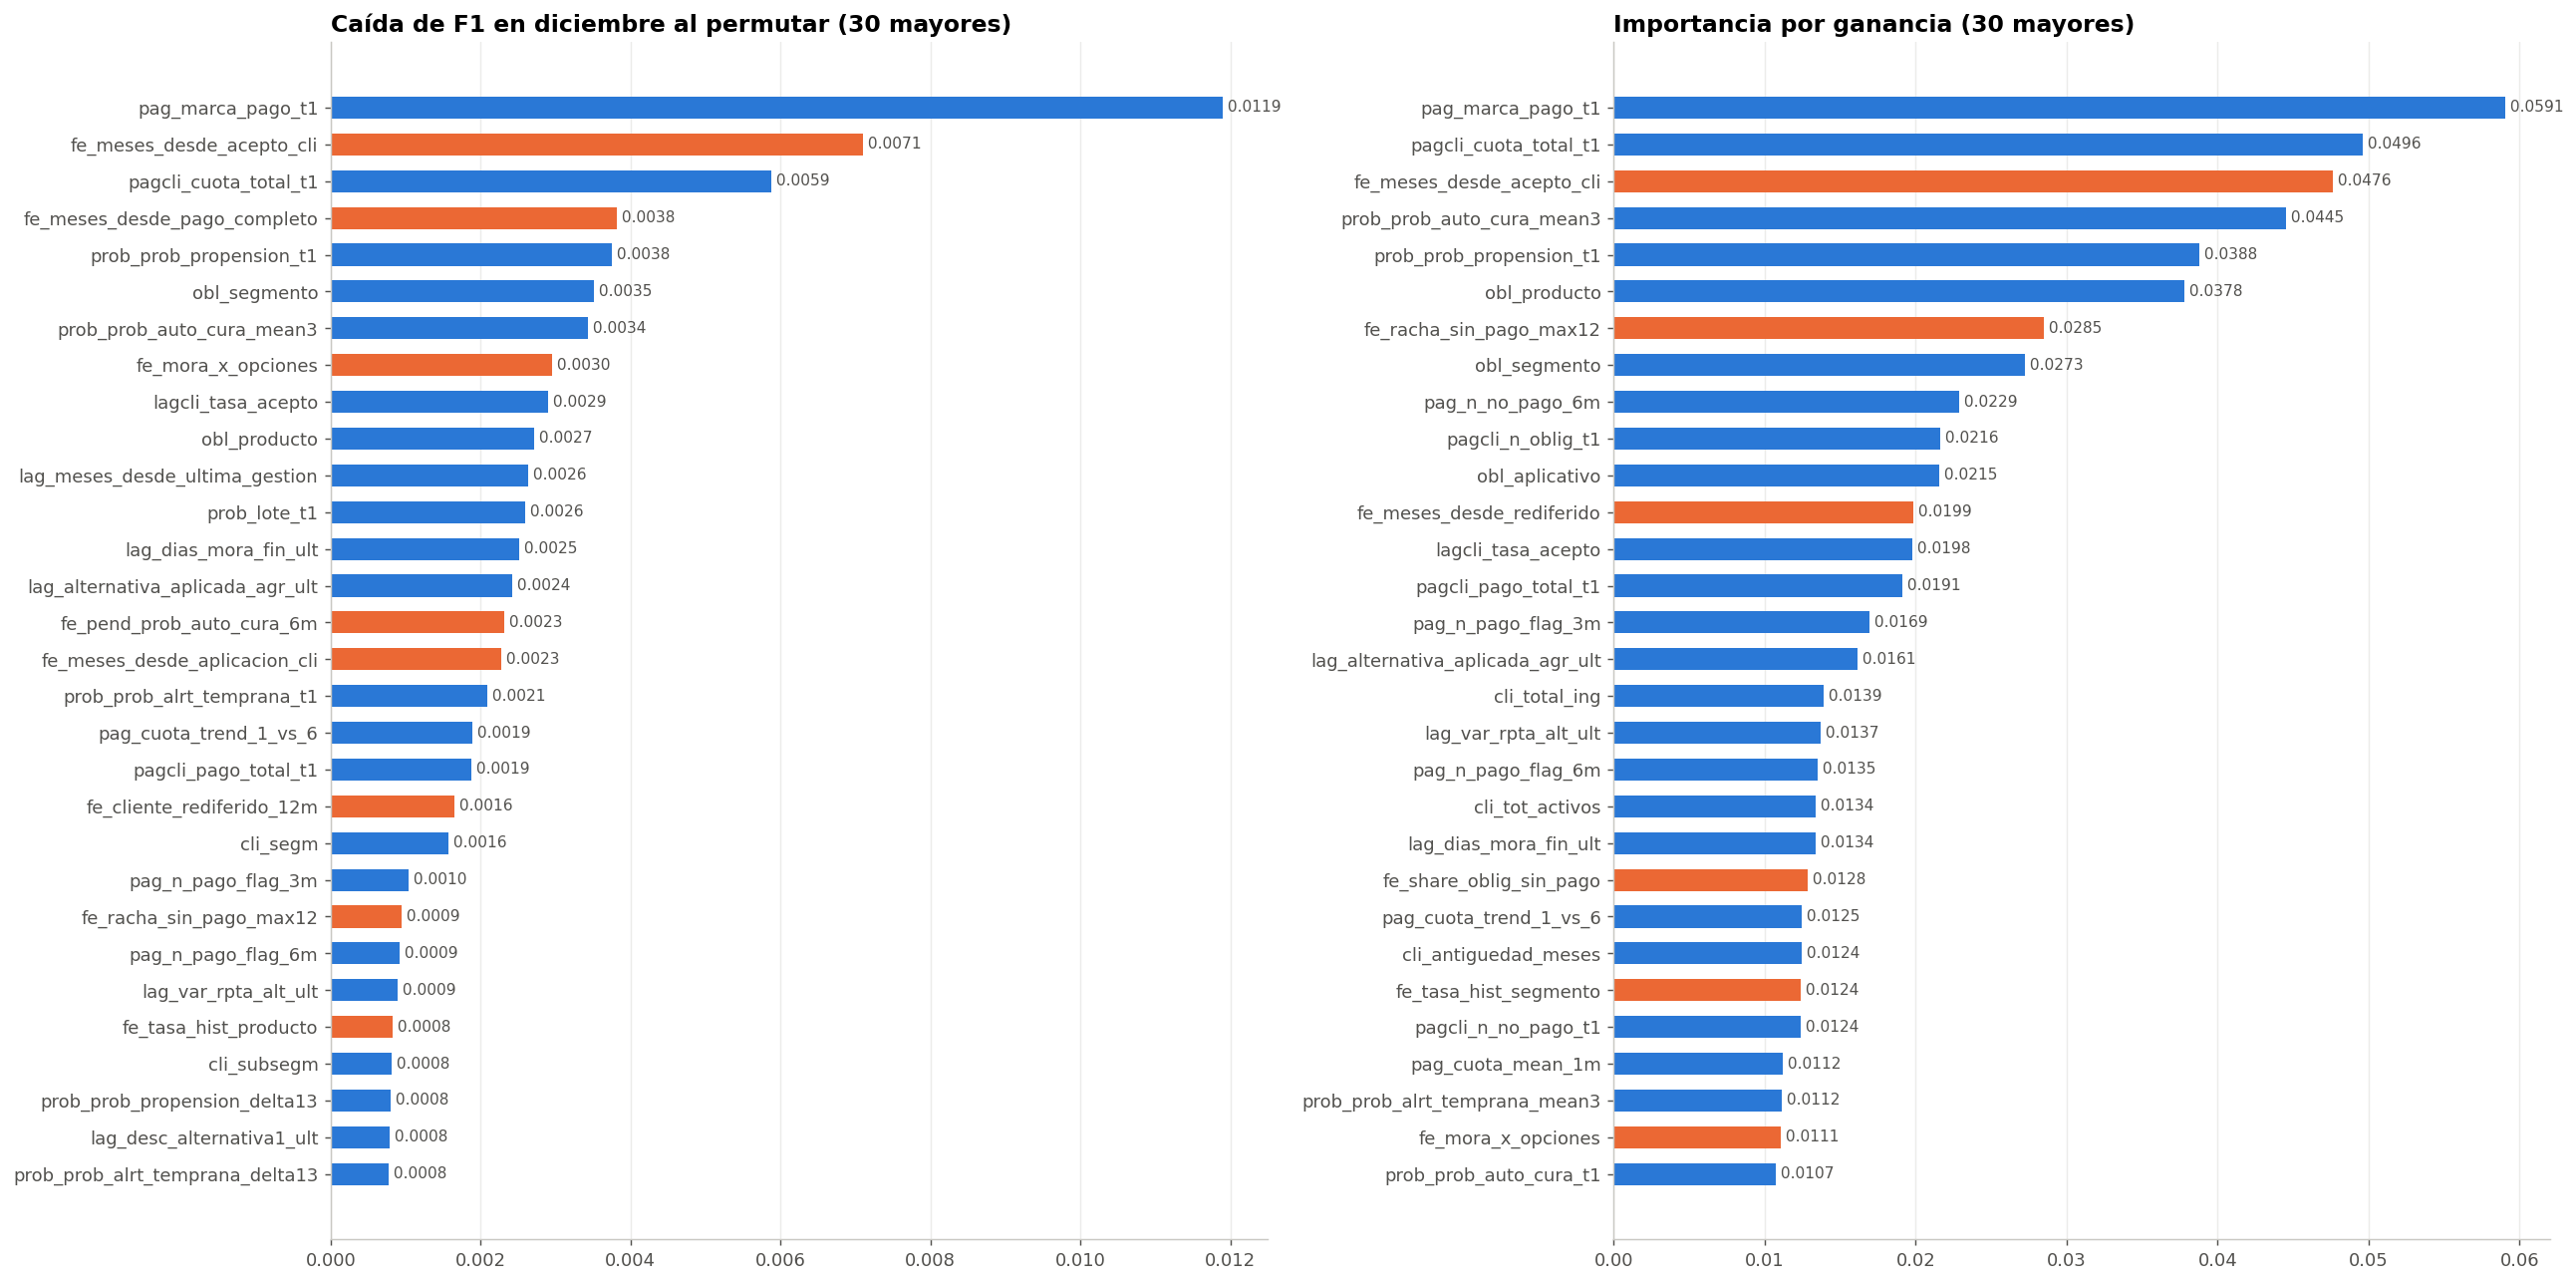

Coinciden en el top 30 de ambas medidas: 17

Variables sin aporte por permutación (caída <= 0): ['pag_n_rediferido_3m', 'lag_n_meses_vistos', 'cli_estado_civil', 'pagcli_n_rediferido_t1', 'pag_n_cancelado_12m', 'cli_genero_cli', 'fe_en_espera', 'cli_num_hijos', 'lagcli_n_aceptos', 'fe_lote_cambio_3m', 'cli_personas_dependientes', 'fe_alerta_sobre_05_3m', 'cli_cli_actualizado', 'cli_declarante', 'lag_cant_alter_posibles_ult', 'pagcli_n_no_pago_t1', 'pag_n_pago_mas_1m', 'cli_t_corte', 'cli_ocup', 'cli_antiguedad_meses', 'pagcli_n_oblig_t1']


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
for ax, s, t in [(axes[0], imp_perm.head(30).iloc[::-1], "Caída de F1 en diciembre al permutar (30 mayores)"), (axes[1], imp_gain.sort_values(ascending=False).head(30).iloc[::-1], "Importancia por ganancia (30 mayores)")]:
    ax.barh(s.index, s.values, color=[C_ORANGE if c.startswith("fe_") else C_BLUE for c in s.index], height=0.6)
    for yv, v in zip(s.index, s.values): ax.text(v, yv, f" {v:.4f}" if v < 0.1 else f" {v:.1%}", va="center", fontsize=8.5, color=C_MUTED)
    ax.set_title(t); ax.grid(axis="y", visible=False)
plt.tight_layout(); fig_imp = fig; plt.show()
print("Coinciden en el top 30 de ambas medidas:", len(set(imp_perm.head(30).index) & set(imp_gain.sort_values(ascending=False).head(30).index)))
print("\nVariables sin aporte por permutación (caída <= 0):", imp_perm[imp_perm <= 0].index.tolist())

## 3. Reentrenamiento por número de variables

Se ordenan las variables por la caída de F1 en la permutación y se reentrena con las 20, 30, 40, 50, 60 y 80 primeras, con la validación temporal de tres cortes. Cada tamaño queda como un run de búsqueda en MLflow.

In [5]:
g = grupo("08_importancia", modelo="lightgbm", **TAGS); g.__enter__()
orden = imp_perm.index.tolist(); res = []
F1_100, DET_100 = evaluar_temporal(FEATS)
registrar_busqueda(0, {"n_vars": 100, "criterio": "todas"}, {"f1_val": F1_100, "f1_dic": DET_100.F1.iloc[-1], "auc_dic": DET_100.AUC.iloc[-1], "f1_oct": DET_100.F1.iloc[0], "f1_nov": DET_100.F1.iloc[1]})
res.append({"n_vars": 100, "F1_prom": F1_100, "F1_dic": DET_100.F1.iloc[-1], "AUC_dic": DET_100.AUC.iloc[-1]})
print(f"100 variables: F1 prom {F1_100:.4f} | dic {DET_100.F1.iloc[-1]:.4f}")
for i, k in enumerate([20, 30, 40, 50, 60, 80], 1):
    t0 = time.time(); cols = orden[:k]; f1m, det = evaluar_temporal(cols)
    registrar_busqueda(i, {"n_vars": k, "criterio": "top_permutacion"}, {"f1_val": f1m, "f1_dic": det.F1.iloc[-1], "auc_dic": det.AUC.iloc[-1], "f1_oct": det.F1.iloc[0], "f1_nov": det.F1.iloc[1], "seg": round(time.time() - t0)})
    res.append({"n_vars": k, "F1_prom": f1m, "F1_dic": det.F1.iloc[-1], "AUC_dic": det.AUC.iloc[-1]})
    print(f"{k:>3} variables: F1 prom {f1m:.4f} | dic {det.F1.iloc[-1]:.4f} | {time.time()-t0:.0f} s")
res = pd.DataFrame(res).sort_values("n_vars"); res.to_csv(OUT / "curva_variables_08.csv", index=False)

100 variables: F1 prom 0.7042 | dic 0.6972


 20 variables: F1 prom 0.6971 | dic 0.6915 | 43 s


 30 variables: F1 prom 0.7017 | dic 0.6961 | 59 s


 40 variables: F1 prom 0.7025 | dic 0.6969 | 68 s


 50 variables: F1 prom 0.7039 | dic 0.6980 | 84 s


 60 variables: F1 prom 0.7041 | dic 0.6983 | 88 s


 80 variables: F1 prom 0.7051 | dic 0.6999 | 110 s


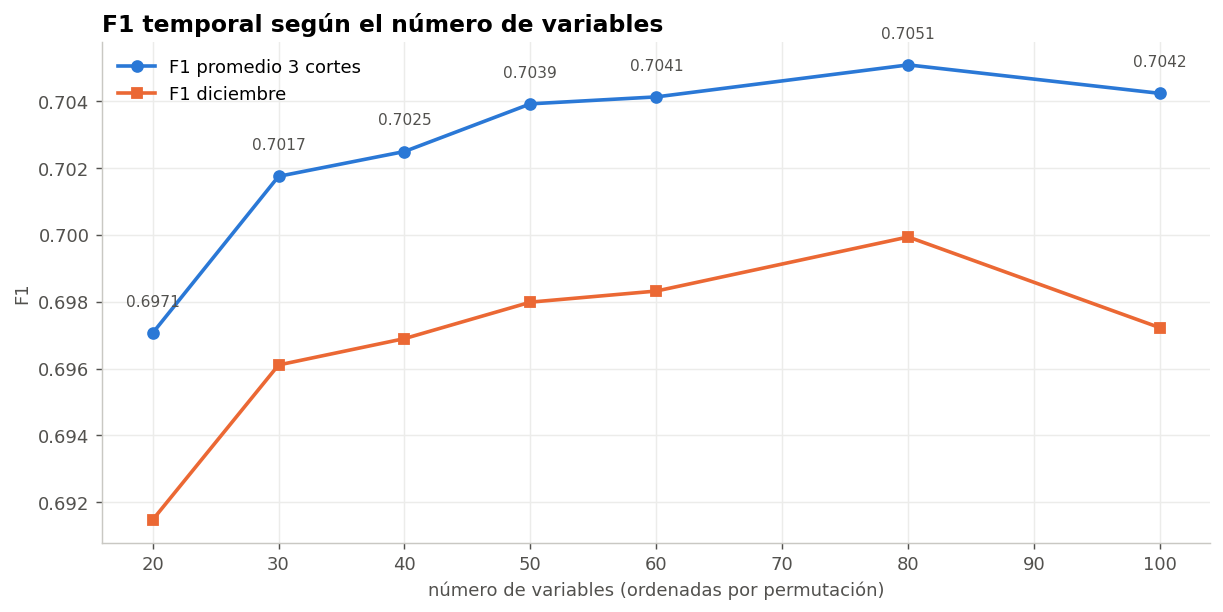

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(res.n_vars, res.F1_prom, marker="o", color=C_BLUE, lw=2, label="F1 promedio 3 cortes"); ax.plot(res.n_vars, res.F1_dic, marker="s", color=C_ORANGE, lw=2, label="F1 diciembre")
for _, r in res.iterrows(): ax.text(r.n_vars, r.F1_prom + 0.0008, f"{r.F1_prom:.4f}", ha="center", fontsize=8.5, color=C_MUTED)
ax.set_xlabel("número de variables (ordenadas por permutación)"); ax.set_ylabel("F1"); ax.legend(frameon=False); ax.set_title("F1 temporal según el número de variables"); fig_curva = fig; plt.show()

## 4. Resultado y Kaggle

Se elige el menor número de variables cuyo F1 promedio quede a menos de 0,001 del mejor. Si ese conjunto es distinto de las 100, se reentrena con los cinco meses y se escribe `submission_v5.csv`. En todo caso el resultado queda registrado.

In [7]:
mejor = res.F1_prom.max(); cand = res[res.F1_prom >= mejor - 0.001].sort_values("n_vars").iloc[0]
K = int(cand.n_vars); FEATS_K = FEATS if K == 100 else orden[:K]
print(f"Mejor F1 prom: {mejor:.4f} | elegido: {K} variables (F1 prom {cand.F1_prom:.4f}, dic {cand.F1_dic:.4f}) | 100 variables: F1 prom {F1_100:.4f}")
m_dic = fit(FEATS_K, 202312); p_dic = m_dic.predict_proba(train.loc[mes == 202312, FEATS_K])[:, 1]; U_K, F1_K = mejor_umbral(y[mes == 202312], p_dic)
pred = p_dic >= U_K; MET = {"f1_dic": F1_K, "auc_dic": roc_auc_score(y[mes == 202312], p_dic), "precision_dic": precision_score(y[mes == 202312], pred), "recall_dic": recall_score(y[mes == 202312], pred), "f1_val": float(cand.F1_prom), "n_arboles": m_dic.best_iteration_}
final = lgb.LGBMClassifier(**P_LGB, n_estimators=m_dic.best_iteration_).fit(train[FEATS_K], y, categorical_feature=[c for c in FEATS_K if c in CAT])
p_oot = final.predict_proba(test[FEATS_K])[:, 1]
ss = pd.read_csv(DATA / "sample_submission.csv", usecols=["ID"])
r = ss.merge(pd.DataFrame({"ID": test.ID.astype(str), "Prob_uno": p_oot}), on="ID", how="left"); r["var_rpta_alt"] = (r.Prob_uno >= U_K).astype(int); assert r.Prob_uno.notna().all()
r[["ID", "var_rpta_alt"]].to_csv(OUT / "submission_v5.csv", index=False); r[["ID", "var_rpta_alt", "Prob_uno"]].round({"Prob_uno": 5}).to_csv(OUT / "resultado_prueba_v5.csv", index=False, encoding="utf-8")
final.booster_.save_model(str(ROOT / "models" / "lgbm_v5.txt")); pd.Series(FEATS_K, name="feature").to_csv(PROC / "features_v5.csv", index=False)
rid = registrar_final({**{k: v for k, v in P_LGB.items() if k not in ("objective", "subsample_freq", "random_state", "verbose", "n_jobs")}, "n_vars": K, "criterio": "top_permutacion"}, {**MET, "pct_pred_1_oot": r.var_rpta_alt.mean()}, U_K, FEATS_K,
                      modelo=final, flavor="lightgbm", ruta_modelo=ROOT / "models" / "lgbm_v5.txt", figuras={"importancia": fig_imp, "curva_variables": fig_curva}, tags={"ganador_08": str(K != 100)})
import mlflow; mlflow.log_artifact(str(OUT / "submission_v5.csv"), artifact_path="kaggle"); mlflow.log_artifact(str(OUT / "importancia_08.csv"))
g.__exit__(None, None, None)
print(f"Final: {K} variables | umbral {U_K:.2f} | F1 dic {F1_K:.4f} | % predicho 1 en oot: {r.var_rpta_alt.mean():.3f}")
resumen("grupo")[["run", "f1_val", "f1_dic", "f1_kaggle_publico"]].tail(4)

Mejor F1 prom: 0.7051 | elegido: 60 variables (F1 prom 0.7041, dic 0.6983) | 100 variables: F1 prom 0.7042


Final: 60 variables | umbral 0.35 | F1 dic 0.6983 | % predicho 1 en oot: 0.613


,run,f1_val,f1_dic,f1_kaggle_publico
11,07_xgb_temporal,0.703339,0.696438,NaN
12,07_xgb_temporal,NaN,NaN,NaN
13,08_importancia,0.704125,0.698318,NaN
14,09_multiclase_ruta,NaN,NaN,NaN
